# agentv8_sequential_workflow — Sequential Workflow with Loop


Graph:

START → planner → sql_agent → evaluator
                     ↑         ↓
                     └─────────┘
                          |
                    final_answer → END


In [1]:
from typing import TypedDict

class AgentState(TypedDict, total=False):
    input: str
    plan: list[str]
    current_step: int
    sql_results: list[str]
    needs_more_sql: bool
    answer: str


In [2]:
def planner_node(state):
    plan = [
        "Query release window",
        "Query failures before release",
        "Query failures after release"
    ]
    return {"plan": plan, "current_step": 0, "sql_results": []}


In [3]:
def sql_agent(state):
    step = state["current_step"]
    plan = state["plan"]
    results = state["sql_results"]
    results.append(f"Executed SQL step {step+1}: {plan[step]}")
    return {"sql_results": results}


In [4]:
def evaluator(state):
    step = state["current_step"] + 1
    total = len(state["plan"])

    if step < total:
        return {"current_step": step, "needs_more_sql": True}
    return {"current_step": step, "needs_more_sql": False}


In [5]:
def final_answer(state):
    summary = "\n".join(state["sql_results"])
    return {"answer": f"Analysis Complete:\n{summary}"}


In [6]:
def route_after_eval(state):
    if state["needs_more_sql"]:
        return "sql_agent"
    return "final_answer"


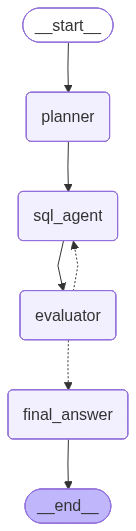

In [9]:
from langgraph.graph import START, END, StateGraph

def build_graph():
    g = StateGraph(AgentState)

    g.add_node("planner", planner_node)
    g.add_node("sql_agent", sql_agent)
    g.add_node("evaluator", evaluator)
    g.add_node("final_answer", final_answer)

    g.add_edge(START, "planner")
    g.add_edge("planner", "sql_agent")
    g.add_edge("sql_agent", "evaluator")

    g.add_conditional_edges(
        "evaluator",
        route_after_eval,
        {
            "sql_agent": "sql_agent",
            "final_answer": "final_answer"
        }
    )

    g.add_edge("final_answer", END)

    return g.compile()

graph = build_graph()

graph


In [8]:
print(graph.get_graph().draw_mermaid())


---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	planner(planner)
	sql_agent(sql_agent)
	evaluator(evaluator)
	final_answer(final_answer)
	__end__([<p>__end__</p>]):::last
	__start__ --> planner;
	evaluator -.-> final_answer;
	evaluator -.-> sql_agent;
	planner --> sql_agent;
	sql_agent --> evaluator;
	final_answer --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [10]:
result = graph.invoke({
    "input":"Analyze EPP failures before and after release"
})
result


{'input': 'Analyze EPP failures before and after release',
 'plan': ['Query release window',
  'Query failures before release',
  'Query failures after release'],
 'current_step': 3,
 'sql_results': ['Executed SQL step 1: Query release window',
  'Executed SQL step 2: Query failures before release',
  'Executed SQL step 3: Query failures after release'],
 'needs_more_sql': False,
 'answer': 'Analysis Complete:\nExecuted SQL step 1: Query release window\nExecuted SQL step 2: Query failures before release\nExecuted SQL step 3: Query failures after release'}